In [87]:
import pandas as pd

#carga de datos 
url = "https://raw.githubusercontent.com/4GeeksAcademy/data-preprocessing-project-tutorial/main/AB_NYC_2019.csv"
df = pd.read_csv(url)

# confirmacion
df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [88]:
# resumen tecnico 
df.info()

# datos nulos 
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [89]:
# borrar columnas que no sirven 
df.drop(['id', 'name', 'host_name', 'last_review'], axis=1, inplace=True)

#rellenar los nulos 
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

#comprobamos 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_id                         48895 non-null  int64  
 1   neighbourhood_group             48895 non-null  str    
 2   neighbourhood                   48895 non-null  str    
 3   latitude                        48895 non-null  float64
 4   longitude                       48895 non-null  float64
 5   room_type                       48895 non-null  str    
 6   price                           48895 non-null  int64  
 7   minimum_nights                  48895 non-null  int64  
 8   number_of_reviews               48895 non-null  int64  
 9   reviews_per_month               48895 non-null  float64
 10  calculated_host_listings_count  48895 non-null  int64  
 11  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usag

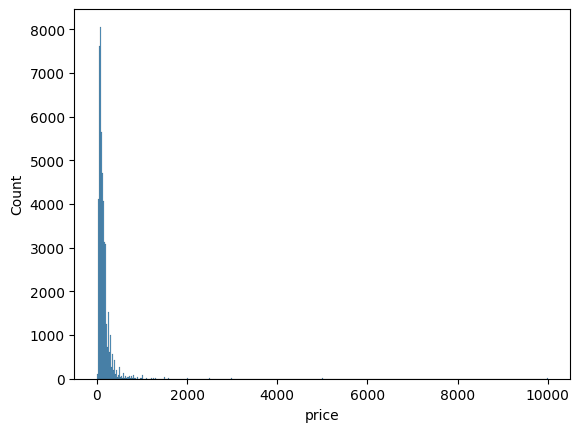

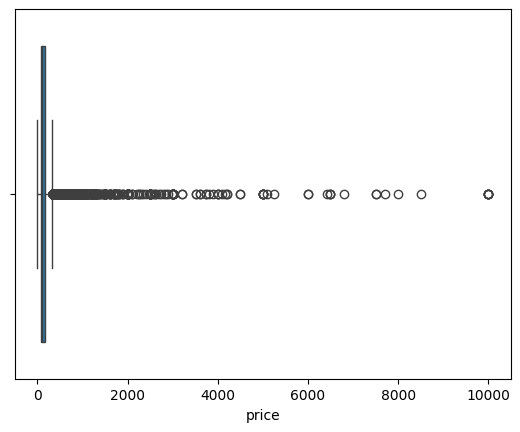

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear histograma de precios
sns.histplot(df['price'])
plt.show()

# Crear gráfico de caja para ver valores locos (outliers)
sns.boxplot(x=df['price'])
plt.show()

conclusion: Existen outliers (precios de $10,000) que afectan el promedio y deben ser filtrados

In [91]:
# Eliminar precios mayores a 1000
df = df[df['price'] < 1000]

# Verificar 
df.shape

(48597, 12)

In [92]:
# resumen estadistico, acá tomamos las tres columnas mas relevantes para lo que buscamso 
resumen = df[['price', 'minimum_nights', 'number_of_reviews']].describe()
resumen

,price,minimum_nights,number_of_reviews
count,48597.000000,48597.000000,48597.000000
mean,140.237299,6.975019,23.375270
std,112.906258,20.275227,44.650882
min,0.000000,1.000000,0.000000
25%,69.000000,1.000000,1.000000
50%,105.000000,3.000000,5.000000
75%,175.000000,5.000000,24.000000
max,999.000000,1250.000000,629.000000


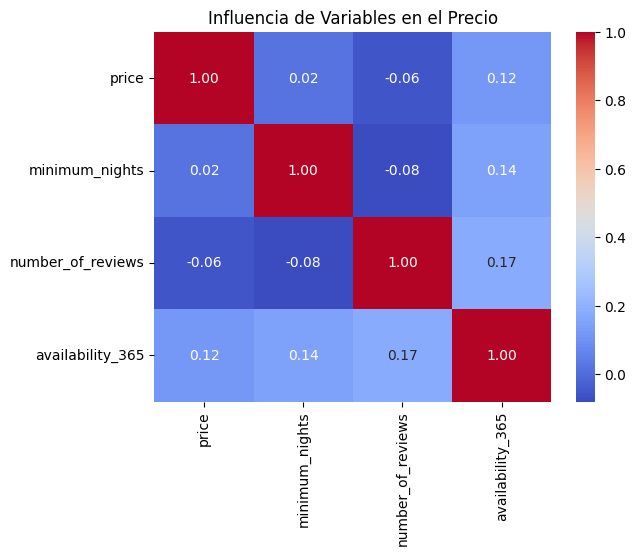

In [93]:
# Matriz filtrada con lo más importante
columnas_clave = ['price', 'minimum_nights', 'number_of_reviews', 'availability_365']
corr_filtrada = df[columnas_clave].corr()

# Dibujar mapa de calor
sns.heatmap(corr_filtrada, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Influencia de Variables en el Precio")
plt.show()

Conclusión: Solo existe correlación relevante (0.59) entre variables de reseñas. El precio depende de factores externos a los numéricos actuales.


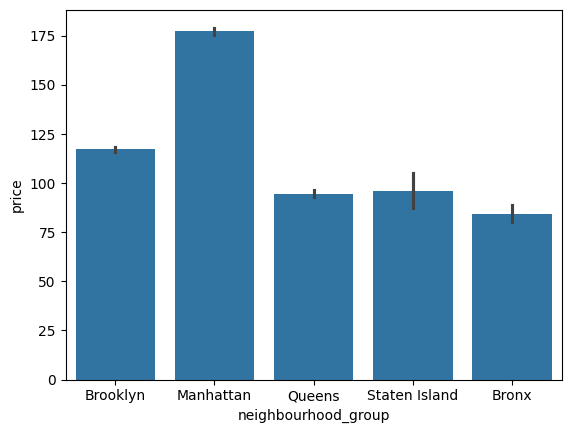

In [94]:
# Gráfico de barras para comparar distritos
sns.barplot(data=df, x='neighbourhood_group', y='price')
plt.show()

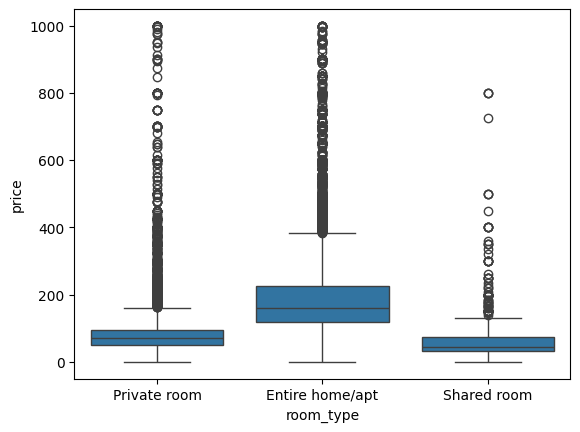

In [95]:
# Gráfico de caja para ver la dispersión por tipo de habitación
sns.boxplot(data=df, x='room_type', y='price')
plt.show()

In [96]:
# Convertir categorías en números
df = pd.get_dummies(df, columns=['neighbourhood_group', 'room_type'])

# Mostrar las nuevas columnas creadas
df.head()

,host_id,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,2787,Kensington,40.64749,-73.97237,149,1,9,0.21,6,365,False,True,False,False,False,False,True,False
1,2845,Midtown,40.75362,-73.98377,225,1,45,0.38,2,355,False,False,True,False,False,True,False,False
2,4632,Harlem,40.80902,-73.94190,150,3,0,0.00,1,365,False,False,True,False,False,False,True,False
3,4869,Clinton Hill,40.68514,-73.95976,89,1,270,4.64,1,194,False,True,False,False,False,True,False,False
4,7192,East Harlem,40.79851,-73.94399,80,10,9,0.10,1,0,False,False,True,False,False,True,False,False


In [97]:
from sklearn.model_selection import train_test_split

# Definir variables (X) y el objetivo (y)
X = df.drop('price', axis=1)
y = df['price']

# Dividir el dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificar tamaños
X_train.shape, X_test.shape

((38877, 17), (9720, 17))

In [98]:
# 1. Limpieza absoluta: Solo nos quedamos con lo que es número o Booleano (True/False)
df_model = df.select_dtypes(include=['number', 'bool'])

# 2. Definir X (características) e y (objetivo)
X = df_model.drop('price', axis=1)
y = df_model['price']

# 3. División de datos
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Entrenamiento
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

print("¡Modelo entrenado con éxito!")

¡Modelo entrenado con éxito!


In [100]:
# 1. Filtro de precios para eliminar ruido
df = df[(df['price'] > 0) & (df['price'] < 500)].copy()

# 2. Expulsión total de texto (Elimina 'East Harlem' y cualquier string)
df_final = df.select_dtypes(include=['number', 'bool'])

# 3. Definición de variables
X = df_final.drop(columns=['price'], errors='ignore')
y = df_final['price']

# 4. División y Entrenamiento
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# 5. Generar predicciones para la evaluación
y_pred = model.predict(X_test)

print(f"Modelo entrenado. Columnas usadas: {list(X.columns)}")

Modelo entrenado. Columnas usadas: ['host_id', 'latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'neighbourhood_group_Bronx', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island', 'room_type_Entire home/apt', 'room_type_Private room', 'room_type_Shared room']


In [101]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Calcular el Error Cuadrático Medio (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# 2. Calcular la precisión (R2 Score)
r2 = r2_score(y_test, y_pred)

print(f"Error promedio (RMSE): {rmse:.2f}")
print(f"Precisión (R2 Score): {r2:.2f}")

Error promedio (RMSE): 64.59
Precisión (R2 Score): 0.42


In [103]:
import os

# 1. Definición de la ruta (Path)
path = './data/processed/'

# 2. Verificación y creación de directorios
if not os.path.exists(path):
    os.makedirs(path)

# 3. Persistencia de datos (Exportación)
X_train.to_csv(f'{path}X_train_processed.csv', index=False)
X_test.to_csv(f'{path}X_test_processed.csv', index=False)
y_train.to_csv(f'{path}y_train_processed.csv', index=False)
y_test.to_csv(f'{path}y_test_processed.csv', index=False)

print("¡Archivos guardados con éxito!")

¡Archivos guardados con éxito!
